### Фокин Никита 5130901/30201
## Упражнения по главе 1.

### Упражнение 1.2

В ходе выполнения данного задания был загружен аудио файл с сайта freesound.org, при этом появилась необходимость изменения кода модуля thinkdsp.py: в строке 112 fromstring был заменен на frombuffer, так как в новых версиях Python fromstring устарел, что вызывало следующую ошибку:

In [1]:
# ValueError: The binary mode of fromstring is removed, use frombuffer instead

In [2]:
from thinkdsp import read_wave

perc_wave = read_wave('744675__samusounds79__145-hat-loop-t9xj5.wav')
perc_wave.normalize()
perc_wave.make_audio()

Таким образом, был получен следующий сигнал:

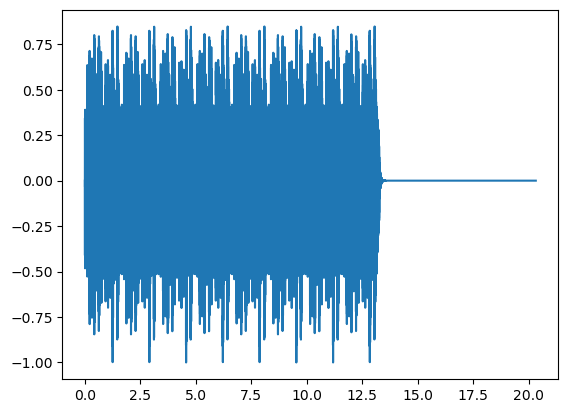

In [3]:
perc_wave.plot()

Из этого сигнала был выделен фрагмент длиной в 0.15 секунд, имеющий примерно постоянную высоту

In [4]:
perc_segment = perc_wave.segment(start=1.27, duration=0.15)
perc_segment.make_audio()

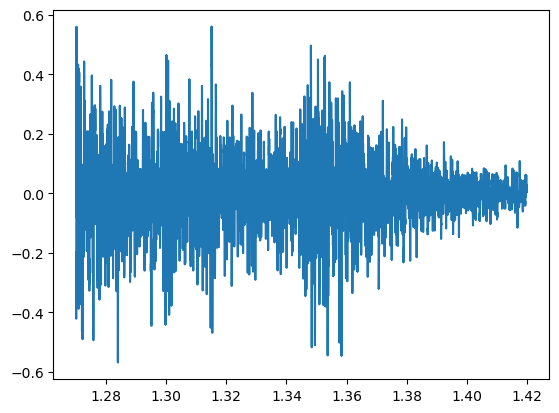

In [5]:
perc_segment.plot()

Был получен его спектр:

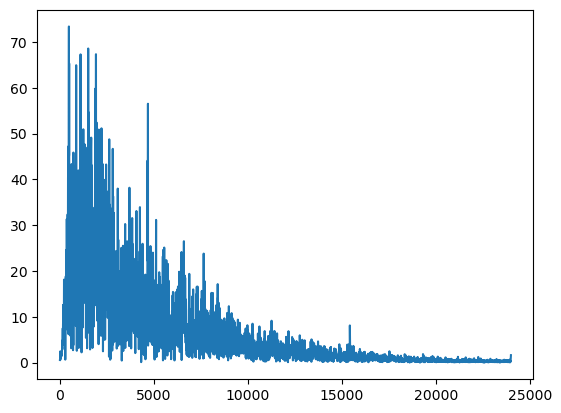

In [6]:
spectrum = perc_segment.make_spectrum()
spectrum.plot()

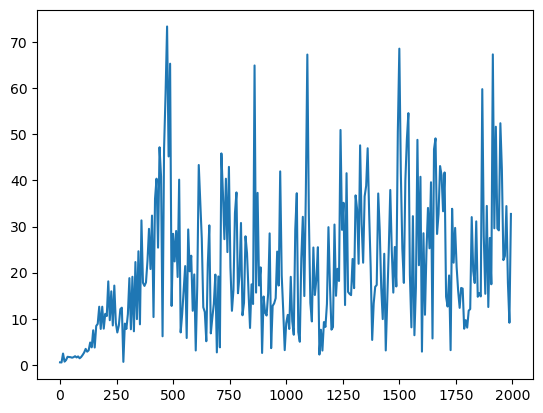

In [7]:
spectrum.plot(high=2000)

Были найдены его максимумы:

In [8]:
spectrum.peaks()[:10]

[(np.float64(73.40673922775933), np.float64(473.33333333333337)),
 (np.float64(68.59479073061117), np.float64(1500.0)),
 (np.float64(67.34753311444338), np.float64(1913.3333333333335)),
 (np.float64(67.31106686844123), np.float64(1093.3333333333335)),
 (np.float64(65.33149097691286), np.float64(486.6666666666667)),
 (np.float64(64.94578780092323), np.float64(860.0)),
 (np.float64(59.806219724797636), np.float64(1866.6666666666667)),
 (np.float64(58.96381795320814), np.float64(466.6666666666667)),
 (np.float64(56.525820761927314), np.float64(4680.0)),
 (np.float64(54.604185598383886), np.float64(1540.0))]

Несущая частота - 473.3 Гц, при этом также основные максимумы находятся в следующих частотах: 1500.0, 1913.3, 
1093.3 и 486.67 Гц.

После этого с помощью фильтров были получены различные гармоники сигнала:

In [9]:
spectrum.high_pass(2000)
spectrum.make_wave().make_audio()

In [10]:
spectrum.low_pass(2800)
spectrum.make_wave().make_audio()

In [11]:
spectrum.band_stop(5000, 10000)
spectrum.make_wave().make_audio()

Таким образом, при применении high_pass получаем спектр, состоящий из более высоких частот сигнала. С учетом того, что в упражнении рассматривается сигнал с выраженной высотой (удар тарелки на барабанной установке), то этот сегмент кажется наиболее громким из трех представленных. При использовании low_pass обрезаются высокие частоты, и, следовательно, звук тарелки кажется приглушенным, а band_stop в свою очередь позволяет ослабить частоты между заданными нижней и верхней границами в 5000 и 10000 соответсвенно, и в данном случае на слух сигнал кажется похожим на фильтрованный по низким частотам.


### Упражнение 1.3

В ходе выполнения данного упражнения был создан сложный сигнал из объектов модуля thinkdsp.

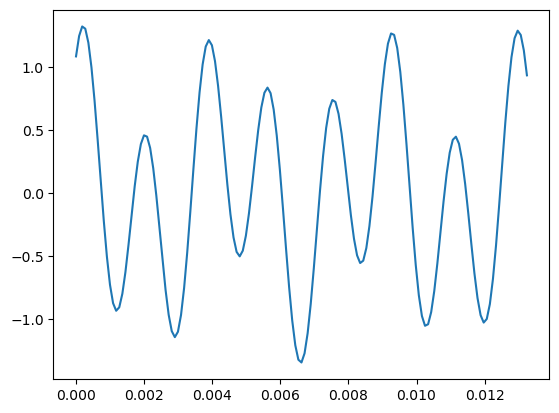

In [12]:
from thinkdsp import SinSignal, CosSignal
from math import pi 

s = SinSignal(freq=550, amp=0.9, offset=pi/4)
c = CosSignal(freq=225, amp=0.45, offset=0)

mix = s + c

mix.plot()

Этот сигнал был получен с помощью make_wave:

In [13]:
wave = mix.make_wave(duration=1, start=0, framerate=11025)

In [14]:
from IPython.display import Audio
audio = Audio(data=wave.ys, rate=wave.framerate)
audio

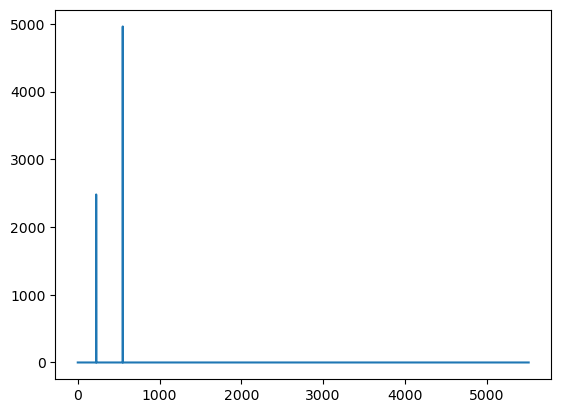

In [15]:
spectrum = wave.make_spectrum()
spectrum.plot()

In [16]:
spectrum.peaks()[:2]

[(np.float64(4961.250000000001), np.float64(550.0)),
 (np.float64(2480.6250000000005), np.float64(225.0))]

Таким образом, сигнал имеет основную частоту в 225 Гц и ярко выраженную гармонику в 550 Гц, которая также является ее доминирующей частотой.

При добавлении частотных компонент, не равных основным, но находящихся в кратном соотношении с ними (например, 3/2), могут возникать более сложные тембры.
Если же такое отношение иррационально, то появляются дополнительные пики в спектре, которые не укладываются в гармноическую сетку, что приводит к возникновению диссонанса. Это более характерно для ударных инструментов. 

В следующем примере диссонанса сигналы различаются на полутон:

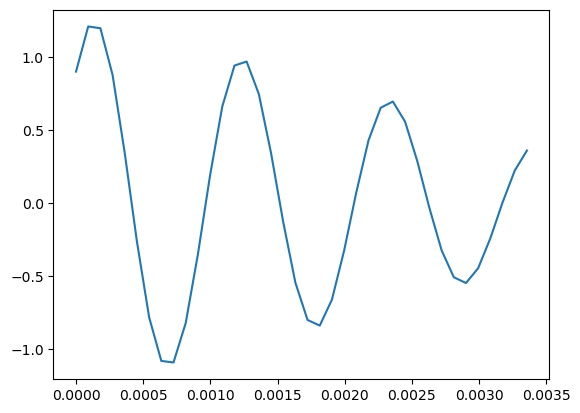

In [17]:
s_diss = SinSignal(freq=880, amp=0.9, offset=0)
c_diss = CosSignal(freq=880 * 2**(1/12), amp=0.9, offset=0)

mix_diss = s_diss + c_diss

mix_diss.plot()

In [18]:
wave_diss = mix_diss.make_wave(duration=1, start=0, framerate=11025)
audio_diss = Audio(data=wave_diss.ys, rate=wave_diss.framerate)
audio_diss

### Упражнение 1.4

В ходе выполнения данного задания была составлена функция для замедления поступающего на вход сигнала в k раз:

In [19]:
def stretch(wave, k):
    wave.ts *= k
    wave.framerate /= k
    

Сигнал до изменения:

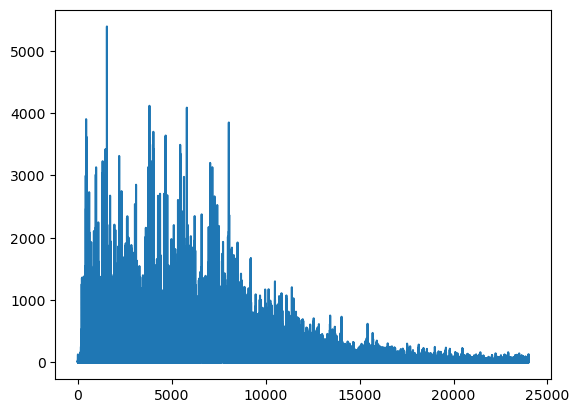

In [20]:
spec_before = perc_wave.make_spectrum();
spec_before.plot()

Сигнал после изменения:

In [21]:
stretch(perc_wave, 5)
perc_wave.make_audio()

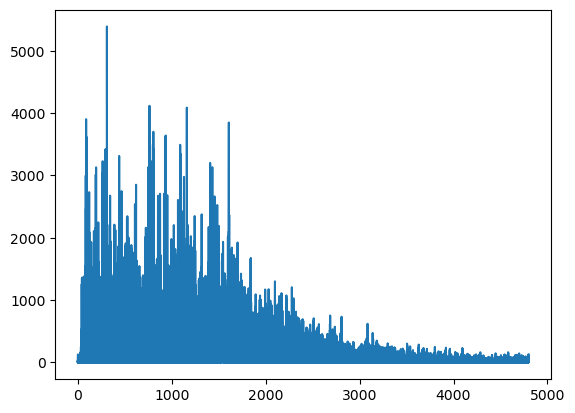

In [22]:
spec_after = perc_wave.make_spectrum();
spec_after.plot()

Из двух спектров видно, что гармоники сигнала сместились ближе к нулевому значению частоты, при этом сам вид графика не изменился.